# K-Means Clustering of Pacing Archetypes

Cluster analysis of pacing profiles for **all** Berlin Marathon runners who targeted a sub-3 h finish, combining both the Success (< 3 h) and Failure (≥ 3 h) cohorts.

Each runner's 9-segment pace profile is **shape-normalised** (divided by their own mean pace) so that clusters capture *pacing pattern* rather than absolute speed. We then cross-tabulate cluster membership with race outcome to identify which archetypes are associated with success or failure.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load both cohorts
success = pd.read_csv('../data/cohort_success.csv')
failure = pd.read_csv('../data/cohort_failure.csv')

# Add outcome column
success['outcome'] = 'Success'
failure['outcome'] = 'Failure'

# Combine
combined = pd.concat([success, failure], ignore_index=True)

print(f"Success cohort : {len(success):,} runners")
print(f"Failure cohort : {len(failure):,} runners")
print(f"Combined       : {len(combined):,} runners")
print(f"\nOutcome distribution:\n{combined['outcome'].value_counts()}")
print(f"\nColumns: {combined.shape[1]}")

Success cohort : 7,710 runners
Failure cohort : 1,875 runners
Combined       : 9,585 runners

Outcome distribution:
outcome
Success    7710
Failure    1875
Name: count, dtype: int64

Columns: 27


## Cluster Validation

Pace matrix shape: (9585, 9)
Example normalised row (runner 0): [0.8257 0.8257 0.8241 0.8691 0.9806 1.1757 1.2563 1.2421 1.0007]


k=2  inertia=136.88  silhouette=0.5602


k=3  inertia=108.16  silhouette=0.4845


k=4  inertia=95.28  silhouette=0.3593


k=5  inertia=85.01  silhouette=0.3025


k=6  inertia=77.05  silhouette=0.2983


k=7  inertia=71.85  silhouette=0.2857


k=8  inertia=68.23  silhouette=0.2284

>>> Optimal k by silhouette score: 2


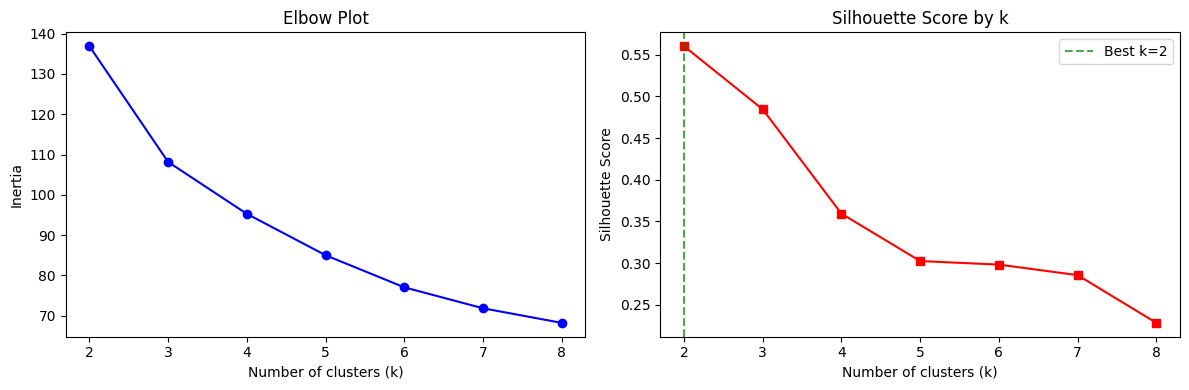

Saved: ../figures/clustering_validation.png


In [2]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

PACE_COLS = [
    'pace_05k', 'pace_510k', 'pace_1015k', 'pace_1520k',
    'pace_2025k', 'pace_2530k', 'pace_3035k', 'pace_3540k', 'pace_40End'
]

# Shape-normalise: divide each pace by the runner's mean pace
# This clusters on pacing PATTERN, not absolute speed
pace_data = combined[PACE_COLS].copy()
runner_mean_pace = pace_data.mean(axis=1)
pace_norm = pace_data.div(runner_mean_pace, axis=0)

print(f"Pace matrix shape: {pace_norm.shape}")
print(f"Example normalised row (runner 0): {pace_norm.iloc[0].values.round(4)}")

# Evaluate k = 2..8
K_range = range(2, 9)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(pace_norm)
    inertias.append(km.inertia_)
    sil = silhouette_score(pace_norm, labels)
    silhouettes.append(sil)
    print(f"k={k}  inertia={km.inertia_:.2f}  silhouette={sil:.4f}")

optimal_k = list(K_range)[np.argmax(silhouettes)]
print(f"\n>>> Optimal k by silhouette score: {optimal_k}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(K_range), inertias, 'bo-')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Plot')
axes[0].set_xticks(list(K_range))

axes[1].plot(list(K_range), silhouettes, 'rs-')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')
axes[1].set_xticks(list(K_range))
axes[1].axvline(x=optimal_k, color='green', linestyle='--', alpha=0.7, label=f'Best k={optimal_k}')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/clustering_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../figures/clustering_validation.png")

## Final Clustering

In [3]:
# Final K-Means with optimal k
print(f"Running K-Means with k={optimal_k}, random_state=42\n")

km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
combined['cluster'] = km_final.fit_predict(pace_norm)

# Compute mean ACTUAL pace profile per cluster (not normalised)
cluster_profiles = combined.groupby('cluster')[PACE_COLS].mean()

print("=== Mean pace profiles per cluster (sec/km) ===")
print(cluster_profiles.round(2).to_string())
print()

# Analyse each centroid to assign descriptive labels
labels_map = {}
for c in range(optimal_k):
    profile = cluster_profiles.loc[c]
    start_pace = profile.iloc[:2].mean()   # first 10 km
    end_pace = profile.iloc[-2:].mean()    # last ~7 km
    mid_pace = profile.iloc[3:6].mean()    # 15-30 km
    cv = profile.std() / profile.mean() * 100  # CV in %

    # Classification logic
    pace_change = (end_pace - start_pace) / start_pace * 100  # % change

    if cv < 1.5 and abs(pace_change) < 3:
        label = "Even Pace"
    elif pace_change < -2:
        label = "Negative Split"
    elif pace_change > 10:
        label = "Metabolic Crash"
    elif pace_change > 3:
        label = "Positive Split / Fade"
    else:
        label = "Mild Positive Split"

    labels_map[c] = label
    print(f"Cluster {c}: start_pace={start_pace:.1f}, end_pace={end_pace:.1f}, "
          f"change={pace_change:+.1f}%, CV={cv:.2f}% → \"{label}\"")

# Apply labels
combined['cluster_label'] = combined['cluster'].map(labels_map)

print(f"\n=== Cluster sizes ===")
print(combined['cluster_label'].value_counts().to_string())
print(f"\nTotal: {len(combined):,}")

Running K-Means with k=2, random_state=42

=== Mean pace profiles per cluster (sec/km) ===
         pace_05k  pace_510k  pace_1015k  pace_1520k  pace_2025k  pace_2530k  pace_3035k  pace_3540k  pace_40End
cluster                                                                                                         
0            4.20       4.19        4.19        4.20        4.23        4.26        4.28        4.38        4.28
1            4.09       4.09        4.11        4.16        4.29        4.53        4.87        5.36        5.20

Cluster 0: start_pace=4.2, end_pace=4.3, change=+3.2%, CV=1.48% → "Positive Split / Fade"
Cluster 1: start_pace=4.1, end_pace=5.3, change=+29.1%, CV=11.07% → "Metabolic Crash"

=== Cluster sizes ===
cluster_label
Positive Split / Fade    7127
Metabolic Crash          2458

Total: 9,585


## Cross-Tabulation: Cluster × Outcome

In [4]:
from scipy.stats import chi2_contingency

# Contingency table: cluster_label × outcome
ct = pd.crosstab(combined['cluster_label'], combined['outcome'])
ct_pct = pd.crosstab(combined['cluster_label'], combined['outcome'], normalize='index') * 100

print("=== Contingency Table (counts) ===")
print(ct.to_string())
print()

print("=== Contingency Table (% within cluster) ===")
print(ct_pct.round(1).to_string())
print()

# Chi-squared test
chi2, p, dof, expected = chi2_contingency(ct)
print(f"Chi-squared test of independence:")
print(f"  χ² = {chi2:.2f}")
print(f"  df = {dof}")
print(f"  p  = {p:.2e}")
print(f"  {'Significant (p < 0.05)' if p < 0.05 else 'Not significant'}")
print()

# Summary: which archetypes predict failure?
print("=== Failure rate by pacing archetype ===")
for label in ct_pct.index:
    fail_pct = ct_pct.loc[label, 'Failure']
    n = ct.loc[label].sum()
    print(f"  {label:30s}  Failure: {fail_pct:5.1f}%  (n={n:,})")

=== Contingency Table (counts) ===
outcome                Failure  Success
cluster_label                          
Metabolic Crash           1752      706
Positive Split / Fade      123     7004

=== Contingency Table (% within cluster) ===
outcome                Failure  Success
cluster_label                          
Metabolic Crash           71.3     28.7
Positive Split / Fade      1.7     98.3

Chi-squared test of independence:
  χ² = 5614.33
  df = 1
  p  = 0.00e+00
  Significant (p < 0.05)

=== Failure rate by pacing archetype ===
  Metabolic Crash                 Failure:  71.3%  (n=2,458)
  Positive Split / Fade           Failure:   1.7%  (n=7,127)


In [5]:
# Save combined dataset with cluster columns
combined.to_csv('../data/cohort_clustered.csv', index=False)
print(f"Saved: ../data/cohort_clustered.csv")
print(f"Shape: {combined.shape}")
print(f"New columns: 'outcome', 'cluster', 'cluster_label'")

Saved: ../data/cohort_clustered.csv
Shape: (9585, 29)
New columns: 'outcome', 'cluster', 'cluster_label'
